In [26]:
# import sys
#from podio import root_io
import uproot 
import awkward as ak
import math
import vector
import numpy as np
path = "/work/eic/users/aabhishe/EIC_3He_5x41_XRot_pi_bc.hepmc3.tree_sim_output_recon.root"

In [27]:
import ROOT
import awkward as ak
import numpy as np
import uproot

# Open the file and access the tree
tree = uproot.open(f"{path}:events")

# --- Extract Roman Pot Arrays ---
rp_x = tree["ForwardRomanPotHits.position.x"].array()
rp_y = tree["ForwardRomanPotHits.position.y"].array()
rp_z = tree["ForwardRomanPotHits.position.z"].array()

# --- Extract Off-Momentum Tracker Arrays ---
om_x = tree["ForwardOffMTrackerHits.position.x"].array()
om_y = tree["ForwardOffMTrackerHits.position.y"].array()
om_z = tree["ForwardOffMTrackerHits.position.z"].array()

# --- Define Z-Range Masks ---
# Roman Pots (assuming +/- 100 mm window around the center points)
rp_z1_mask =  (rp_z < 32600)
rp_z2_mask = (rp_z > 34200) 

# Off-Momentum Trackers (assuming +/- 100 mm window)
om_z1_mask = (om_z < 25600) 
om_z2_mask = (om_z > 26800) 

# --- Helper Function to Create and Fill Histograms ---
def fill_histogram(name, title, x_arr, y_arr, mask, x_bins, y_bins):
    # Apply mask and convert to float64 numpy arrays
    x_vals = ak.to_numpy(ak.flatten(x_arr[mask])).astype(np.float64)
    y_vals = ak.to_numpy(ak.flatten(y_arr[mask])).astype(np.float64)
    weights = np.ones(len(x_vals), dtype=np.float64)
    
    # Create histogram
    hist = ROOT.TH2F(name, title, x_bins[0], x_bins[1], x_bins[2], y_bins[0], y_bins[1], y_bins[2])
    
    # Fill histogram if data exists
    if len(x_vals) > 0:
        hist.FillN(len(x_vals), x_vals, y_vals, weights)
        
    # Apply axis labels
    hist.GetXaxis().SetTitle("X Position [mm]")
    hist.GetYaxis().SetTitle("Y Position [mm]")
    
    return hist

# --- Generate Histograms ---
# Note: Adjust the Off-Momentum Tracker bin limits if your hits fall outside these estimated ranges
h_rp1 = fill_histogram("h_rp1", "Roman Pot Station 1 (Z ~ 32.5m)", rp_x, rp_y, rp_z1_mask, (100, -1300, -950), (100, -90, 90))
h_rp2 = fill_histogram("h_rp2", "Roman Pot Station 2 (Z ~ 34.3m)", rp_x, rp_y, rp_z2_mask, (100, -1400, -1050), (100, -90, 90))

h_om1 = fill_histogram("h_om1", "Off-Momentum Tracker Station 1 (Z ~ 25.6m)", om_x, om_y, om_z1_mask, (100, -1000, -850), (100, -100, 100))
h_om2 = fill_histogram("h_om2", "Off-Momentum Tracker Station 2 (Z ~ 26.9m)", om_x, om_y, om_z2_mask, (100, -1050, -940), (100, -100, 100))

# --- Canvas 1: Roman Pots ---
canvas_rp = ROOT.TCanvas("canvas_rp", "Roman Pot Hits", 1200, 600)
canvas_rp.Divide(2, 1) # Divide canvas into 1 row, 2 columns

canvas_rp.cd(1)
h_rp1.Draw("COLZ")

canvas_rp.cd(2)
h_rp2.Draw("COLZ")

canvas_rp.SaveAs("./Plots/rompot_hits_xy_both_stations.png")

# --- Canvas 2: Off-Momentum Trackers ---
canvas_om = ROOT.TCanvas("canvas_om", "Off-Momentum Tracker Hits", 1400, 600)
canvas_om.Divide(2, 1) 

canvas_om.cd(1)
h_om1.GetYaxis().SetTitleOffset(1.1)
h_om1.Draw("COLZ")

canvas_om.cd(2)
h_om2.GetYaxis().SetTitleOffset(1.1)
h_om2.Draw("COLZ")

canvas_om.SaveAs("./Plots/offm_tracker_hits_xy_both_stations.png")

Warning in <TROOT::Append>: Replacing existing TH1: h_rp1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_rp2 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_om1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_om2 (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_rp
Info in <TCanvas::Print>: png file ./Plots/rompot_hits_xy_both_stations.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_om
Info in <TCanvas::Print>: png file ./Plots/offm_tracker_hits_xy_both_stations.png has been created


In [30]:
import ROOT
import awkward as ak
import numpy as np
import uproot



# --- Extract B0 Tracker Arrays ---
b0_x = tree["B0TrackerHits.position.x"].array()
b0_y = tree["B0TrackerHits.position.y"].array()
b0_z = tree["B0TrackerHits.position.z"].array()

# --- Define Z-Range Masks for the 4 Stations ---
# Windows of +/- 50 mm around the peaks observed in the 1D Z-histogram
b0_z1_mask =  (b0_z < 6000)
b0_z2_mask = (b0_z > 6100) & (b0_z < 6300)
b0_z3_mask = (b0_z > 6400) & (b0_z < 6500)
b0_z4_mask = (b0_z > 6600) 

# --- Helper Function to Create and Fill Histograms ---
def fill_histogram(name, title, x_arr, y_arr, mask, x_bins, y_bins):
    # Apply mask and convert to float64 numpy arrays
    x_vals = ak.to_numpy(ak.flatten(x_arr[mask])).astype(np.float64)
    y_vals = ak.to_numpy(ak.flatten(y_arr[mask])).astype(np.float64)
    weights = np.ones(len(x_vals), dtype=np.float64)
    
    # Create histogram
    hist = ROOT.TH2F(name, title, x_bins[0], x_bins[1], x_bins[2], y_bins[0], y_bins[1], y_bins[2])
    
    # Fill histogram if data exists
    if len(x_vals) > 0:
        hist.FillN(len(x_vals), x_vals, y_vals, weights)
        
    # Apply axis labels and adjust offset
    hist.GetXaxis().SetTitle("X Position [mm]")
    hist.GetYaxis().SetTitle("Y Position [mm]")
    hist.GetYaxis().SetTitleOffset(0.9) 
    
    return hist

# --- Generate Histograms ---
# X and Y bin ranges derived from the 1D coordinate histograms
x_binning = (100, -350, 0)
y_binning = (100, -200, 200)

h_b0_1 = fill_histogram("h_b0_1", "B0 Tracker Station 1 (Z ~ 5900 mm)", b0_x, b0_y, b0_z1_mask, x_binning, y_binning)
h_b0_2 = fill_histogram("h_b0_2", "B0 Tracker Station 2 (Z ~ 6180 mm)", b0_x, b0_y, b0_z2_mask, x_binning, y_binning)
h_b0_3 = fill_histogram("h_b0_3", "B0 Tracker Station 3 (Z ~ 6440 mm)", b0_x, b0_y, b0_z3_mask, x_binning, y_binning)
h_b0_4 = fill_histogram("h_b0_4", "B0 Tracker Station 4 (Z ~ 6700 mm)", b0_x, b0_y, b0_z4_mask, x_binning, y_binning)

# --- Draw and Save Canvas ---
canvas_b0 = ROOT.TCanvas("canvas_b0", "B0 Tracker Hits", 1200, 1000)
canvas_b0.Divide(2, 2) # Divide canvas into a 2x2 grid

canvas_b0.cd(1)
h_b0_1.Draw("COLZ")

canvas_b0.cd(2)
h_b0_2.Draw("COLZ")

canvas_b0.cd(3)
h_b0_3.Draw("COLZ")

canvas_b0.cd(4)
h_b0_4.Draw("COLZ")

canvas_b0.SaveAs("./Plots/b0_tracker_hits_xy_all_stations.png")

Warning in <TROOT::Append>: Replacing existing TH1: h_b0_1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_b0_2 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_b0_3 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_b0_4 (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_b0
Info in <TCanvas::Print>: png file ./Plots/b0_tracker_hits_xy_all_stations.png has been created


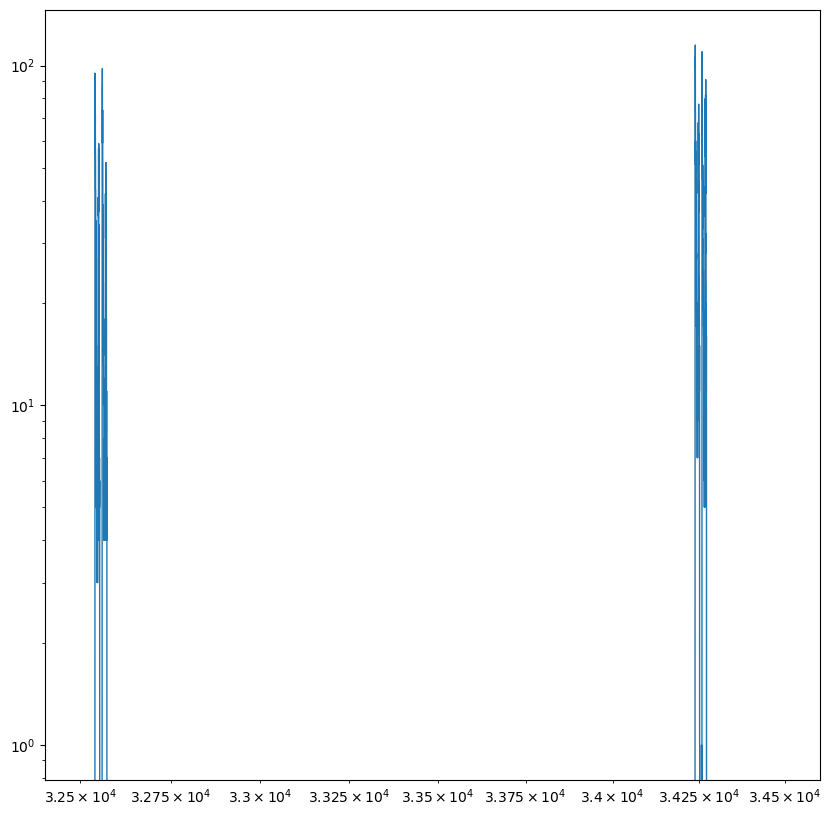

In [7]:
import matplotlib.pyplot as plt
rompots_g4_z_flat = ak.flatten(rompots_g4_z)
plt.figure(figsize=(10, 10))
log_bins = np.logspace(np.log10(3.25e+04), np.log10(3.45e+04), 10000)
plt.hist(rompots_g4_z_flat, bins=log_bins, range=(3.20e+04, 3.45e+04), histtype='step', label='G4 Hits Y')
plt.xscale('log')
plt.yscale('log')
plt.show()


In [3]:
tree = uproot.open(f"{path}:events")

# Read arrays
e_prime_pdg_arrays = tree["ReconstructedChargedParticles.PDG"].array()
e_beam_pdg_arrays = tree["MCParticles.PDG"].array()
e_prime_mc_pdg_arrays = tree["MCParticles.PDG"].array()
mc_gen_status = tree["MCParticles.generatorStatus"].array()

#e_beam_energy = 5.0
#p_beam_energy = 41.0

e_prime_mask = (e_prime_pdg_arrays == 11) 
e_prime_mc_mask = (e_prime_mc_pdg_arrays == 11) & (mc_gen_status == 1)

e_beam_mask = (e_beam_pdg_arrays == 11) & (mc_gen_status == 4)
p_beam_mask = (e_beam_pdg_arrays == 1000020030 ) & (mc_gen_status == 4)
# Apply masks for scattered (reco) electrons
e_prime_pz = tree["ReconstructedChargedParticles.momentum.z"].array()[e_prime_mask]
e_prime_px = tree["ReconstructedChargedParticles.momentum.x"].array()[e_prime_mask]
e_prime_py = tree["ReconstructedChargedParticles.momentum.y"].array()[e_prime_mask]
e_prime_E = tree["ReconstructedChargedParticles.energy"].array()[e_prime_mask]

# Apply masks for scattered (MC truth) electrons
e_prime_mc_pz = tree["MCParticles.momentum.z"].array()[e_prime_mc_mask]
e_prime_mc_px = tree["MCParticles.momentum.x"].array()[e_prime_mc_mask]
e_prime_mc_py = tree["MCParticles.momentum.y"].array()[e_prime_mc_mask]
e_prime_mc_E = np.sqrt(e_prime_mc_px**2 + e_prime_mc_py**2 + e_prime_mc_pz**2 + 0.000511**2)


# Apply masks for beam (MC truth) electrons
e_beam_pz = tree["MCParticles.momentum.z"].array()[e_beam_mask]
e_beam_px = tree["MCParticles.momentum.x"].array()[e_beam_mask]
e_beam_py = tree["MCParticles.momentum.y"].array()[e_beam_mask]
# e_beam_E = ak.full_like(e_beam_pz, e_beam_energy)
e_beam_mass = 0.000511  # Electron mass in GeV
e_beam_E = np.sqrt(e_beam_px**2 + e_beam_py**2 + e_beam_pz**2 + e_beam_mass**2)

p_beam_pz = tree["MCParticles.momentum.z"].array()[p_beam_mask]
p_beam_px = tree["MCParticles.momentum.x"].array()[p_beam_mask]
p_beam_py = tree["MCParticles.momentum.y"].array()[p_beam_mask]
# p_beam_E = ak.full_like(p_beam_pz, p_beam_energy)
p_beam_mass = 2.8084  # Helium-3 mass in GeV
p_beam_E = np.sqrt(p_beam_px**2 + p_beam_py**2 + p_beam_pz**2 + p_beam_mass**2)



e_beam = vector.zip({
    "px": e_beam_px,
    "py": e_beam_py,
    "pz": e_beam_pz,
    "E": e_beam_E
})

e_prime = vector.zip({
    "px": e_prime_px,
    "py": e_prime_py,
    "pz": e_prime_pz,
    "E": e_prime_E
})

e_prime_mc = vector.zip({
    "px": e_prime_mc_px,
    "py": e_prime_mc_py,
    "pz": e_prime_mc_pz,
    "E": e_prime_mc_E
})

p_beam = vector.zip({
    "px": p_beam_px,
    "py": p_beam_py,
    "pz": p_beam_pz,
    "E": p_beam_E
})
sorted_indices = ak.argsort(e_prime.E, ascending=False)
e_prime_sorted = e_prime[sorted_indices]

sorted_indices_mc = ak.argsort(e_prime_mc.E, ascending=False)
e_prime_mc_sorted = e_prime_mc[sorted_indices_mc]


print(f"e_beam: {e_beam[:10]}")
e_beam_single = ak.firsts(e_beam)
print('e_beam_single:', e_beam_single[:10])
p_beam_single = ak.firsts(p_beam)
e_prime_leading = ak.firsts(e_prime_sorted)
e_prime_mc_leading = ak.firsts(e_prime_mc_sorted)

#four momentum transfer
q = e_beam_single - e_prime_leading
Q2 = -q.mass2
q_mc = e_beam_single - e_prime_mc_leading
Q2_mc = -q_mc.mass2
#bjorken x
x = 3.*Q2 / (2. * p_beam_single.dot(q))
x_mc = 3.*Q2_mc / (2. * p_beam_single.dot(q_mc))

print(f"Q2: {Q2[:10]}")
print(f"x: {x[:10]}")
Q2_clean = ak.to_numpy(ak.drop_none(Q2)).astype(np.float64)
x_clean = ak.to_numpy(ak.drop_none(x)).astype(np.float64)

Q2_mc_clean = ak.to_numpy(ak.drop_none(Q2_mc)).astype(np.float64)
x_mc_clean = ak.to_numpy(ak.drop_none(x_mc)).astype(np.float64)


e_beam: [[{x: 0.000592, y: -0.00112, z: -5, t: 5}], ..., [{x: -0.000111, y: ..., ...}]]
e_beam_single: [{x: 0.000592, y: -0.00112, z: -5, t: 5}, ..., {x: -0.000111, y: 0.000222, ...}]
Q2: [2.48, 2.27, 1.66, 1.43, 2.55, 1.06, 1.18, 1.52, 3.92, 20.6]
x: [0.0305, 0.0243, 0.0243, 0.0273, 0.00567, ..., 0.0127, 0.0166, 0.0111, 0.129]


In [ ]:
import ROOT
Q2_bin_edges = np.logspace(-1, 3, 101)  # 100 bins from 10^-2 to 10^2

Q2_hist = ROOT.TH1F("his1", "Q2 Distribution; Q2 [GeV^2]; Events", len(Q2_bin_edges) - 1, Q2_bin_edges)
xbj_bin_edges = np.logspace(-4, 0, 101)  # 100 bins from 10^-4 to 10^-1
x_hist = ROOT.TH1F("his2", "Bjorken x Distribution; x; Events", len(xbj_bin_edges) - 1, xbj_bin_edges)
Q2_mc_hist = ROOT.TH1F("his3", "Q2 MC Distribution; Q2 [GeV^2]; Events", len(Q2_bin_edges) - 1, Q2_bin_edges)
x_mc_hist = ROOT.TH1F("his4", "Bjorken x MC Distribution; x; Events", len(xbj_bin_edges) - 1, xbj_bin_edges)

Q2_hist.FillN(len(Q2_clean), Q2_clean, np.ones(len(Q2_clean), dtype=np.float64))
x_hist.FillN(len(x_clean), x_clean, np.ones(len(x_clean), dtype=np.float64))
Q2_mc_hist.FillN(len(Q2_mc_clean), Q2_mc_clean, np.ones(len(Q2_mc_clean), dtype=np.float64))
x_mc_hist.FillN(len(x_mc_clean), x_mc_clean, np.ones(len(x_mc_clean), dtype=np.float64))

Q2_xbj_2d_hist = ROOT.TH2F("his2D", "Q2 vs Bjorken x; Q2 [GeV^2]; x", len(Q2_bin_edges) - 1, Q2_bin_edges, len(xbj_bin_edges) - 1, xbj_bin_edges)

Q2_hist.FillN(len(Q2_clean), Q2_clean, np.ones(len(Q2_clean), dtype=np.float64))
x_hist.FillN(len(x_clean), x_clean, np.ones(len(x_clean), dtype=np.float64))
Q2_xbj_2d_hist.FillN(len(Q2_clean), Q2_clean, x_clean, np.ones(len(Q2_clean), dtype=np.float64))
canvas= ROOT.TCanvas("canvas", "Q2 and x Distributions", 800, 600)
canvas1= ROOT.TCanvas("canvas1", "Q2 vs x Distribution", 800, 600)
canvas1.cd()
canvas1.SetLogy()
canvas1.SetLogx()
canvas1.SetLogz()
Q2_xbj_2d_hist.Draw("COLZ")
canvas1.SaveAs("/home/aabhishe/eic/EIC_Full_Sim/debug/Q2_x_2D_distribution_debug.pdf")
canvas.Divide(2, 1)
canvas.cd(1)
ROOT.gPad.SetLogy()
ROOT.gPad.SetLogx()
Q2_hist.Draw()
Q2_mc_hist.SetLineColor(ROOT.kRed)
Q2_mc_hist.Draw("SAME")
canvas.cd(2)
ROOT.gPad.SetLogx()
ROOT.gPad.SetLogy()
x_hist.Draw()
x_mc_hist.SetLineColor(ROOT.kRed)
x_mc_hist.Draw("SAME")



canvas.SaveAs("/home/aabhishe/eic/EIC_Full_Sim/debug/Q2_x_distributions_debug.pdf")


Info in <TCanvas::Print>: pdf file /home/aabhishe/eic/EIC_Full_Sim/debug/Q2_x_2D_distribution_debug.pdf has been created
Info in <TCanvas::Print>: pdf file /home/aabhishe/eic/EIC_Full_Sim/debug/Q2_x_distributions_debug.pdf has been created


In [ ]:
e_prime = vector.zip({
    "px": momentum_x_arrays,
    "py": momentum_y_arrays,
    "pz": momentum_z_arrays,
    "E": energy_arrays
})

In [ ]:
print(e_prime.pt[3])
print(e_prime.eta[3])